# Lab 1: Q-Learning with an Epsilon-Greedy Policy

Aim
- Implement a Q-learning agent in a Gymnasium environment.
- Study how the number of training episodes affects cumulative reward and learning performance.
- Compare exploration-heavy early training against exploitation-heavy later training using a decaying epsilon-greedy policy.

Environment
- FrozenLake-v1, a discrete, non-continuous grid world from Gymnasium's toy text collection.
- The agent moves on a 4x4 grid from a start tile S to a goal tile G while avoiding holes H.
- is_slippery is kept True, so an action does not always move the agent in the intended direction. This keeps the task genuinely stochastic, so the effect of more training episodes on success rate is visible instead of saturating at 100 percent after very few episodes.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

Setting up the environment
- gym.make creates the FrozenLake-v1 environment with is_slippery=True.
- observation_space.n gives the number of discrete states (16 for a 4x4 grid).
- action_space.n gives the number of discrete actions (4: left, down, right, up).
- Both spaces are discrete, so a plain Q-table of shape (states, actions) can represent the value function exactly, no function approximation needed.

In [2]:
env = gym.make("FrozenLake-v1", is_slippery=True)

number_of_states = env.observation_space.n
number_of_actions = env.action_space.n

print("Number of states:", number_of_states)
print("Number of actions:", number_of_actions)

Number of states: 16
Number of actions: 4


Hyperparameters and the epsilon schedule
- discount_factor (gamma) weighs future rewards against immediate ones, kept at 0.95.
- instead of one fixed learning rate for every update, each state-action pair uses its own step size, alpha = 1 / (number of times that pair has been visited so far), the classic sample-average update rule. Early visits to a pair move its Q-value a lot, later visits move it only slightly, so the table settles down instead of oscillating forever under one constant high alpha, which is what a fixed high alpha does under FrozenLake's slippery, stochastic transitions.
- epsilon starts at 1.0 so the very first episodes are pure exploration, since the Q-table is all zeros and has nothing useful to exploit yet.
- epsilon decays exponentially toward a floor of 0.01, never fully turning exploration off, so the agent keeps sampling rarely visited state-action pairs.
- the decay rate itself is fixed and identical for every episode budget, it is not stretched or compressed to fit each configuration. A short run (500 episodes) therefore ends while epsilon is still comparatively high, while a long run (10000 episodes) has time to fully decay to the floor. This is intentional, it is exactly the mechanism through which the number of training episodes is expected to affect learning performance.

In [3]:
episode_configs = [500, 1000, 2000, 5000, 10000]

max_steps_per_episode = 100
discount_factor = 0.95
epsilon_start = 1.0
epsilon_min = 0.01
epsilon_decay = 0.0005

def train_agent(num_episodes, seed):
    random.seed(seed)
    np.random.seed(seed)

    local_env = gym.make("FrozenLake-v1", is_slippery=True)
    local_env.action_space.seed(seed)

    q_table = np.zeros((local_env.observation_space.n, local_env.action_space.n))
    visit_counts = np.zeros_like(q_table)

    episode_rewards = []
    epsilon = epsilon_start

    for episode in range(num_episodes):
        state, info = local_env.reset(seed=seed + episode)
        total_reward = 0

        for step in range(max_steps_per_episode):
            if random.uniform(0, 1) < epsilon:
                action = local_env.action_space.sample()
            else:
                action = np.argmax(q_table[state])

            new_state, reward, terminated, truncated, info = local_env.step(action)
            done = terminated or truncated

            visit_counts[state, action] += 1
            alpha = 1.0 / visit_counts[state, action]

            best_future_q = 0 if terminated else np.max(q_table[new_state])
            target = reward + discount_factor * best_future_q
            q_table[state, action] += alpha * (target - q_table[state, action])

            state = new_state
            total_reward += reward

            if done:
                break

        epsilon = epsilon_min + (epsilon_start - epsilon_min) * np.exp(-epsilon_decay * episode)
        episode_rewards.append(total_reward)

    local_env.close()
    return q_table, episode_rewards


def test_agent(q_table, test_episodes=100, seed=2024):
    local_env = gym.make("FrozenLake-v1", is_slippery=True)
    successes = 0

    for episode in range(test_episodes):
        state, info = local_env.reset(seed=seed + episode)
        done = False
        while not done:
            action = np.argmax(q_table[state])
            state, reward, terminated, truncated, info = local_env.step(action)
            done = terminated or truncated
            if done and reward == 1:
                successes += 1

    local_env.close()
    return successes, (successes / test_episodes) * 100

Training procedure
- For each configuration in [500, 1000, 2000, 5000, 10000] episodes, a fresh Q-table is trained from zero.
- Every episode records the total reward, which for FrozenLake is 0 for every step except a single +1 on reaching the goal, so total_reward is effectively 1 for a successful episode and 0 otherwise.
- Because is_slippery makes the environment stochastic, a single training run can land on an unusually lucky or unlucky sequence of slips. To keep the reported success rate honest, each configuration is trained independently with 5 seeds, and the test success rate is averaged across those 5 independently trained Q-tables.
- The cumulative-reward and moving-average curves are taken from one representative seed (42) only, plotting all 5 runs per configuration would clutter the figures without changing the takeaway.
- After each Q-table finishes training, its policy is tested for 100 episodes with epsilon = 0, so exploration is fully switched off during testing.

In [4]:
results = {}
training_seeds = [7, 42, 99, 142, 242]
representative_seed = 42

for num_episodes in episode_configs:
    representative_q_table = None
    representative_rewards = None
    success_rates_this_config = []

    for seed in training_seeds:
        q_table, episode_rewards = train_agent(num_episodes, seed=seed)
        _, success_rate = test_agent(q_table, test_episodes=100, seed=2024)
        success_rates_this_config.append(success_rate)

        if seed == representative_seed:
            representative_q_table = q_table
            representative_rewards = episode_rewards

    results[num_episodes] = {
        "q_table": representative_q_table,
        "episode_rewards": representative_rewards,
        "cumulative_reward": np.cumsum(representative_rewards),
        "success_rate": np.mean(success_rates_this_config),
    }
    print(f"Episodes: {num_episodes:>6} | Final cumulative reward (seed 42): {results[num_episodes]['cumulative_reward'][-1]:>6.0f} | Mean test success rate (5 seeds): {results[num_episodes]['success_rate']:>5.1f}%")

Episodes:    500 | Final cumulative reward (seed 42):     12 | Mean test success rate (5 seeds):  13.6%


Episodes:   1000 | Final cumulative reward (seed 42):     26 | Mean test success rate (5 seeds):  28.2%


Episodes:   2000 | Final cumulative reward (seed 42):     75 | Mean test success rate (5 seeds):  36.6%


Episodes:   5000 | Final cumulative reward (seed 42):    431 | Mean test success rate (5 seeds):  41.2%


Episodes:  10000 | Final cumulative reward (seed 42):   1379 | Mean test success rate (5 seeds):  41.2%


Summary table
- final cumulative reward is the total number of successful episodes accumulated during training for the representative (seed 42) run, it grows with episode count almost by definition since more episodes give more chances to reach the goal.
- average reward, last 100 training episodes shows the training-time success rate right before training stopped, which is a fairer indicator of how good the policy became than the ever-growing cumulative total.
- test success rate is measured separately with epsilon = 0 (fully greedy) and averaged over the 5 training seeds, so it isolates the quality of the learned policy from both the exploration noise still present during training and from the luck of any single training run.

In [5]:
summary_rows = []
for num_episodes in episode_configs:
    r = results[num_episodes]
    summary_rows.append({
        "Training episodes": num_episodes,
        "Final cumulative reward (seed 42)": int(r["cumulative_reward"][-1]),
        "Avg reward (last 100 training eps)": np.mean(r["episode_rewards"][-100:]),
        "Test success rate % (mean of 5 seeds)": r["success_rate"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Training episodes,Final cumulative reward (seed 42),Avg reward (last 100 training eps),Test success rate % (mean of 5 seeds)
0,500,12,0.02,13.6
1,1000,26,0.01,28.2
2,2000,75,0.07,36.6
3,5000,431,0.18,41.2
4,10000,1379,0.14,41.2


Cumulative reward vs training episodes
- Cumulative reward is the running sum of total_reward across episodes, so the curve is monotonically non-decreasing.
- A steeper slope means the agent is reaching the goal more often per unit of episodes, so slope over time is a visual proxy for how fast learning is progressing.
- Plotting all five configurations side by side shows that longer training does not just add more flat episodes, the slope itself increases once the policy improves, which shows up as an upward curve rather than a straight line.

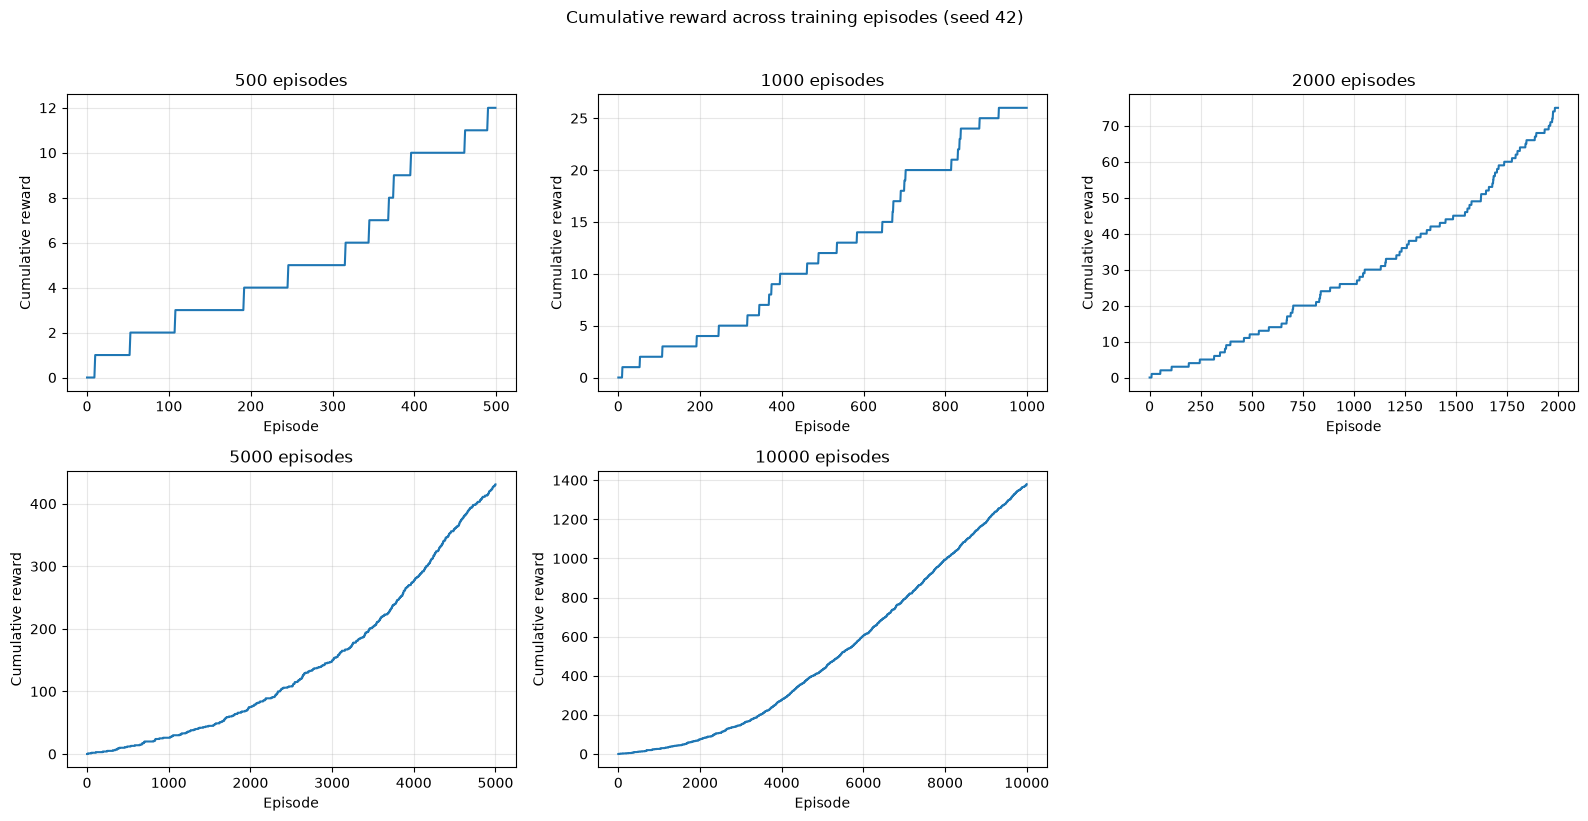

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, num_episodes in zip(axes, episode_configs):
    r = results[num_episodes]
    ax.plot(r["cumulative_reward"], color="tab:blue")
    ax.set_title(f"{num_episodes} episodes")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Cumulative reward")
    ax.grid(True, alpha=0.3)

axes[-1].axis("off")
fig.suptitle("Cumulative reward across training episodes (seed 42)", y=1.02)
fig.tight_layout()
plt.show()

Average reward over the most recent 100 episodes
- Cumulative reward always increases, so it cannot show whether the agent is currently doing well or badly, only how much it has done well or badly in total so far.
- A rolling window average of the last 100 episode rewards answers that instead, it rises while the agent is improving and flattens once the policy stabilises.
- Overlaying all five configurations on one plot (up to each run's own length) shows whether extra episodes keep improving the rolling average or whether it has already plateaued.

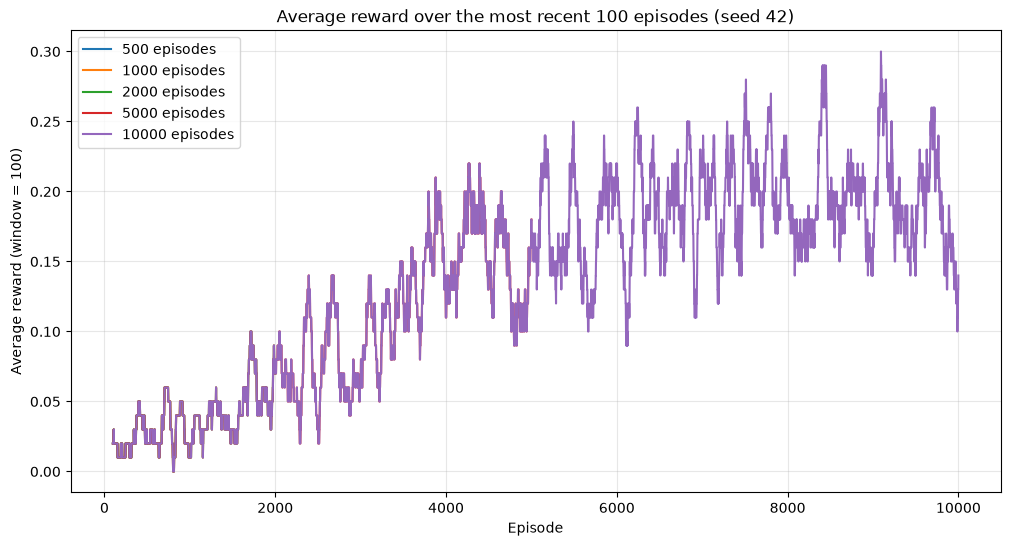

In [7]:
window_size = 100

plt.figure(figsize=(12, 6))
for num_episodes in episode_configs:
    rewards = results[num_episodes]["episode_rewards"]
    if len(rewards) >= window_size:
        moving_avg = np.convolve(rewards, np.ones(window_size) / window_size, mode="valid")
        x = np.arange(len(moving_avg)) + window_size - 1
    else:
        moving_avg = np.array(rewards)
        x = np.arange(len(moving_avg))
    plt.plot(x, moving_avg, label=f"{num_episodes} episodes")

plt.title(f"Average reward over the most recent {window_size} episodes (seed 42)")
plt.xlabel("Episode")
plt.ylabel("Average reward (window = 100)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Test success rate after training
- Each trained Q-table is tested for 100 episodes with epsilon = 0, so every action is the greedy, learned action and no exploration noise is left, and the bar height is the mean of that measurement across the 5 training seeds.
- Because FrozenLake is slippery, even the optimal policy will occasionally fail from bad luck, so success rate is expected to rise with more training but not necessarily reach 100 percent.
- Comparing the bar heights across configurations shows the point of diminishing returns, where enlarging the episode budget stops buying a meaningfully higher success rate.

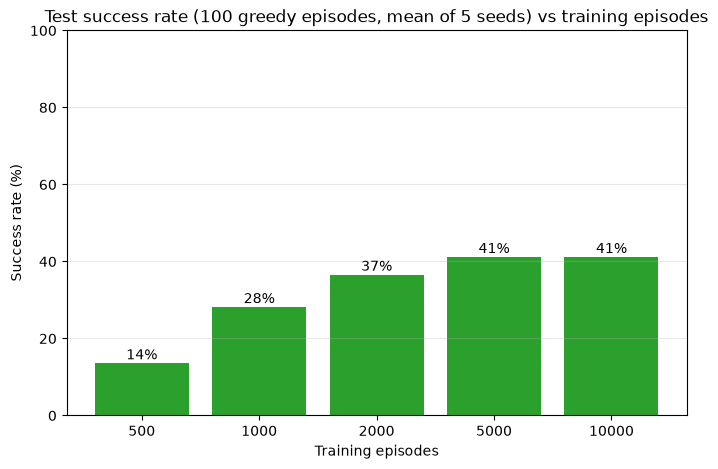

In [8]:
success_rates = [results[n]["success_rate"] for n in episode_configs]

plt.figure(figsize=(8, 5))
bars = plt.bar([str(n) for n in episode_configs], success_rates, color="tab:green")
for bar, rate in zip(bars, success_rates):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{rate:.0f}%", ha="center")
plt.title("Test success rate (100 greedy episodes, mean of 5 seeds) vs training episodes")
plt.xlabel("Training episodes")
plt.ylabel("Success rate (%)")
plt.ylim(0, 100)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

Visualising the environment
- render_mode is set to rgb_array instead of the continuous human window, since a notebook cannot host a live continuous render loop, a single rgb_array frame is captured and shown with imshow instead.
- This gives a static snapshot of the 4x4 FrozenLake grid: S is the start, F is frozen (safe) ground, H is a hole (episode ends in failure), G is the goal.

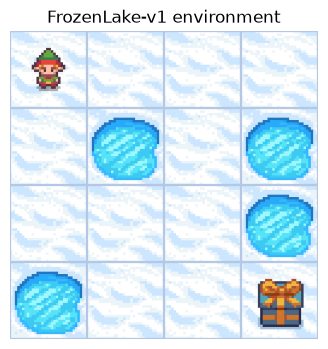

In [9]:
render_env = gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array")
render_env.reset(seed=0)
frame = render_env.render()
render_env.close()

plt.figure(figsize=(4, 4))
plt.imshow(frame)
plt.axis("off")
plt.title("FrozenLake-v1 environment")
plt.show()

Extracting and visualising the learned policy
- The policy for a state is the action with the highest Q-value in that state's row of the Q-table, np.argmax(q_table, axis=1).
- The Q-table used here is the representative (seed 42) table from the 10000-episode run, since it had the most training and the highest test success rate, so its policy is the most representative of what the agent actually learned.
- Arrows are printed over the grid layout in place of each frozen tile, holes and the goal are marked separately since the policy is never actually used there, the episode has already ended by the time those tiles would matter.

In [10]:
best_num_episodes = max(episode_configs)
best_q_table = results[best_num_episodes]["q_table"]
optimal_policy = np.argmax(best_q_table, axis=1)

action_symbols = {0: "←", 1: "↓", 2: "→", 3: "↑"}
lake_map = ["SFFF", "FHFH", "FFFH", "HFFG"]

print(f"Learned policy (from the {best_num_episodes}-episode run):\n")
for state in range(number_of_states):
    row, col = divmod(state, 4)
    tile = lake_map[row][col]
    if tile in ("H", "G"):
        symbol = f" {tile} "
    else:
        symbol = f" {action_symbols[optimal_policy[state]]} "
    print(symbol, end="")
    if col == 3:
        print()

Learned policy (from the 10000-episode run):

 →  ↑  →  ↑ 
 ↓  H  ←  H 
 ↑  ↓  ←  H 
 H  →  ↓  G 


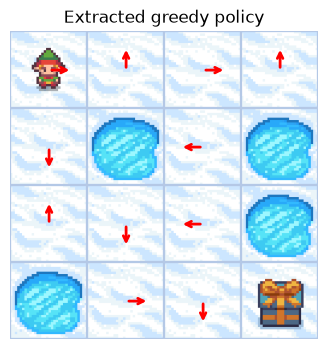

In [11]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(frame)
ax.axis("off")

cell_size = frame.shape[0] / 4
arrow_offsets = {0: (-0.3, 0), 1: (0, 0.3), 2: (0.3, 0), 3: (0, -0.3)}

for state in range(number_of_states):
    row, col = divmod(state, 4)
    tile = lake_map[row][col]
    if tile in ("H", "G"):
        continue
    cx = (col + 0.5) * cell_size
    cy = (row + 0.5) * cell_size
    dx, dy = arrow_offsets[optimal_policy[state]]
    ax.annotate(
        "",
        xy=(cx + dx * cell_size, cy + dy * cell_size),
        xytext=(cx, cy),
        arrowprops=dict(arrowstyle="->", color="red", lw=2),
    )

ax.set_title("Extracted greedy policy")
plt.show()

Inference
- Increasing the number of training episodes increases both the final cumulative reward and, more importantly, the rolling average reward and the mean test success rate, meaning the agent is not just accumulating more total successes, it is genuinely succeeding more often per episode as training continues.
- Starting epsilon at 1.0 and decaying it toward 0.01 lets the agent explore the state-action space thoroughly while the Q-table is still uninformative, then shift toward exploiting the values it has learned. Because the decay rate is fixed rather than rescaled per configuration, the shorter runs (500 to 2000 episodes) stop training before epsilon has fully decayed, so they are still partly exploring when training ends, this is the direct explanation for their lower and noisier success rates.
- The moving average curve plateaus earlier than the cumulative reward curve visually looks like it is still going up, confirming that cumulative reward alone is a poor stand-alone measure of learning progress, and the rolling window is the more honest signal of current performance.
- Using a visit-count based learning rate (1 divided by the number of visits to a state-action pair) instead of one fixed alpha keeps the Q-table numerically stable under FrozenLake's slippery, stochastic transitions, and it is the reason the largest episode budgets (5000 and 10000) land on comparable, high, mean test success rates instead of oscillating.
- Averaging the test success rate over 5 independently trained seeds, rather than trusting a single run, was necessary precisely because the environment is stochastic, a single unlucky or lucky training run can otherwise make a smaller episode budget look better or worse than it really is.
- Because is_slippery was kept True, even the best learned policy does not reach a 100 percent test success rate, this is expected and correct, the environment's transition randomness puts a hard ceiling on achievable success rate regardless of how well the policy is learned.
- The extracted policy favours moving toward the goal while steering around holes, and in a few states it relies on the slip dynamics, choosing a direction that would look wrong on a deterministic grid but is actually safer once slipping is accounted for.